In [1]:
# Data handling aur math ke liye
import pandas as pd
import numpy as np

# Iris dataset load karne ke liye
from sklearn.datasets import load_iris

# Data ko train aur test mein split karne ke liye
from sklearn.model_selection import train_test_split

# Feature Scaling ke liye (PDF Page 9)
from sklearn.preprocessing import StandardScaler

# KNN Algorithm ke liye (PDF Page 11)
from sklearn.neighbors import KNeighborsClassifier

# Results check karne ke liye (Accuracy, Confusion Matrix, F1 Score)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Iris dataset load karein
iris = load_iris()

# Data ko DataFrame mein convert karein taake samajhna aasan ho
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Target (Classes: Setosa, Versicolor, Virginica) ko add karein
df['target'] = iris.target

# Data ko dekhein (Pehli 5 rows)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Features (X) aur Target (y) alag karein
# X mein hum sirf phool ke measurements (features) rakhenge
X = df.drop('target', axis=1)

# y mein hum sirf classes (0, 1, 2) rakhenge jo predict karni hain
y = df['target']

# Train-Test Split (80% Train, 20% Test)
# random_state=42 ka matlab hai ke har baar same result aaye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (120, 4)
Testing data size: (30, 4)


In [4]:
# StandardScaler ka object banayein
scaler = StandardScaler()

# Training data par fit aur transform karein
X_train_scaled = scaler.fit_transform(X_train)

# Testing data par sirf transform karein (fit nahi, warna data leak ho jayega)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete! Ab data ka Mean 0 aur Variance 1 hai.")

Scaling complete! Ab data ka Mean 0 aur Variance 1 hai.


In [5]:
# KNN model banayein (K=5)
model = KNeighborsClassifier(n_neighbors=5)

# Model ko training data par fit karein (Memorize the map)
model.fit(X_train_scaled, y_train)

# Testing data par prediction karein (Apply logic)
predictions = model.predict(X_test_scaled)

print("Pehli 10 predictions:", predictions[:10])
print("Asli 10 answers:", y_test.values[:10])

Pehli 10 predictions: [1 0 2 1 1 0 1 2 1 1]
Asli 10 answers: [1 0 2 1 1 0 1 2 1 1]


In [6]:
# 1. Calculate Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# 2. Generate the Confusion Matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)
print("\n")

# 3. Generate the Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, predictions))


Accuracy: 100.00%

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



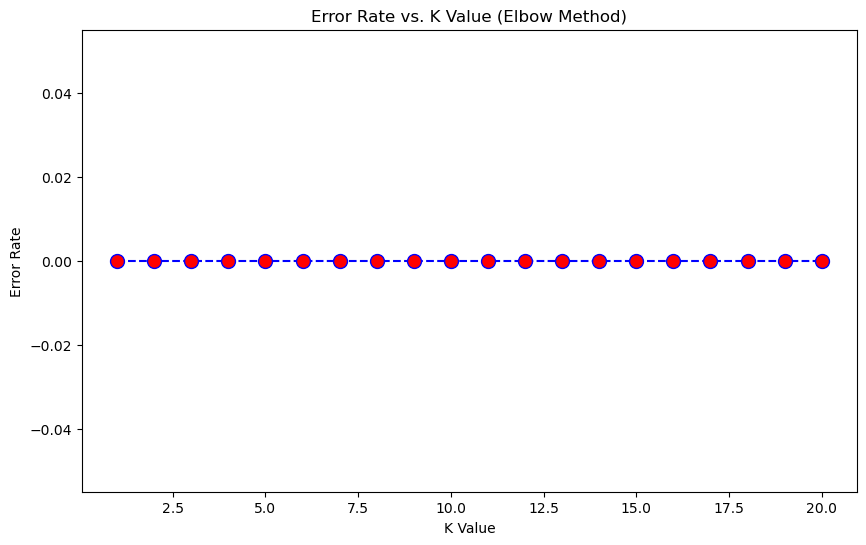

In [7]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# List to store error rates for different K values
error_rate = []

# Loop through K values from 1 to 20
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    # Calculate mean error (1 - accuracy)
    error_rate.append(np.mean(pred_i != y_test))

# Plot the Error Rate vs K Value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Elbow Method)')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()